In [1]:
import pandas as pd

df = pd.read_csv("/content/final_poem_dataset_short_letters.csv",encoding="utf-8-sig",engine="python",on_bad_lines="skip")
print(len(df))

208483


In [2]:
df.shape

(208483, 2)

In [3]:
df.tail(30)

,verse,meter
208453,لو كنت أبغي سواك ما جهلت # نـفـسـي أنّ الصـدود...,المنسرح
208454,فأعينُ القومِ وأذيالها # مصلحةٌ للرشِ والكنسِ,السريع
208455,إِمرَةُ الناسِ هِمَّةٌ لا تَأَنّى # لِجَبانٍ و...,الخفيف
208456,لَهُم رَكايا نَوازِحٌ تَصدُرُ ال # وَفدُ ظِماء...,المنسرح
208457,يغرف من قلب قليب لم يزل # عاديها يهزأ بالحفائر,الرجز
208458,وقد كان ملقاها عبوساً فأصبحت # يهش محياها ويبس...,الطويل
208459,مَن لَم يَمُت عَبطَةً يَمُت هَرِماً # لَلمَوتُ...,المنسرح
208460,وَجَمعٍ سارَ يَقدُمُهُ لِواءٌ # كَفَضلِ عَمامَ...,الوافر
208461,نَفْسي فِداء الغريّ إنّ بهِ # من لا يُسامَى في...,المنسرح
208462,بِفِتيَةٍ كَسُيوفِ الهِندِ لا وَرِعٍ # مِنَ ال...,البسيط


In [4]:
df["meter"].value_counts()

,count
meter,
الرجز,20000
الوافر,20000
السريع,20000
المتقارب,20000
الطويل,20000
الكامل,20000
البسيط,20000
الرمل,20000
الخفيف,20000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208483 entries, 0 to 208482
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   verse   208483 non-null  object
 1   meter   208483 non-null  object
dtypes: object(2)
memory usage: 3.2+ MB


In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["meter"],
    random_state=42)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["meter"],
    random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 145938
Validation: 31272
Test: 31273


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["meter_id"] = le.fit_transform(train_df["meter"])
val_df["meter_id"] = le.transform(val_df["meter"])
test_df["meter_id"] = le.transform(test_df["meter"])

In [9]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(label_mapping)

{'البسيط': np.int64(0), 'الخفيف': np.int64(1), 'الرجز': np.int64(2), 'الرمل': np.int64(3), 'السريع': np.int64(4), 'الطويل': np.int64(5), 'الكامل': np.int64(6), 'المتقارب': np.int64(7), 'المجتث': np.int64(8), 'المنسرح': np.int64(9), 'الوافر': np.int64(10)}


In [10]:
import json
#saving the mapping to a file
label_mapping = {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}

with open("meter_label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

In [11]:
id_to_meter = {int(v): k for k, v in label_mapping.items()}

with open("id_to_meter.json", "w", encoding="utf-8") as f:
    json.dump(id_to_meter, f, ensure_ascii=False, indent=2)

# then during inference (pred_meter = id_to_meter[predicted_class])

In [12]:
train_df.columns

Index(['verse', 'meter', 'meter_id'], dtype='object')

In [13]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)

BATCH_SIZE = 64
EPOCHS = 100
EMBED_DIM = 32
LSTM_UNITS = 128

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

TensorFlow: 2.19.0
Batch size: 64
Epochs: 100


In [14]:
all_text = "".join(train_df["verse"].astype(str))

characters = sorted(list(set(all_text)))

char2idx = {c:i+1 for i,c in enumerate(characters)}
idx2char = {i:c for c,i in char2idx.items()}

vocab_size = len(char2idx) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 90


In [15]:
max_len = train_df["verse"].str.len().max()
print("Max sequence length:", max_len)

Max sequence length: 155


In [16]:
def encode_text(text):
    return [char2idx.get(c,0) for c in text]

In [17]:
X_train = [encode_text(t) for t in train_df["verse"]]
X_val   = [encode_text(t) for t in val_df["verse"]]
X_test  = [encode_text(t) for t in test_df["verse"]]

y_train = train_df["meter_id"].values
y_val   = val_df["meter_id"].values
y_test  = test_df["meter_id"].values

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=max_len, padding="post")
X_val   = pad_sequences(X_val, maxlen=max_len, padding="post")
X_test  = pad_sequences(X_test, maxlen=max_len, padding="post")

num_classes = len(set(y_train))
print("Classes:", num_classes)

Classes: 11


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Bidirectional,Dense,Dropout,LayerNormalization

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=max_len,
        mask_zero=False
    )
)

# First Bidirectional LSTM + LayerNorm + Dropout
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(LayerNormalization())
model.add(Dropout(0.3))

# Second Bidirectional LSTM + LayerNorm
model.add(Bidirectional(LSTM(128)))
model.add(LayerNormalization())
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation="softmax"))

model.build(input_shape=(None, max_len))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 155, 32)        │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 155, 256)       │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 155, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 155, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,835 (2.16 MB)

 Trainable params: 565,835 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [30]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

In [31]:
print("max token:", X_train.max())
print("min token:", X_train.min())
print("vocab_size:", vocab_size)
print("shape:", X_train.shape)

max token: 89
min token: 0
vocab_size: 90
shape: (145938, 155)


In [32]:
history = model.fit( # this is working very well #$%
    X_train,
    y_train,
    batch_size=BATCH_SIZE, # started 10:14 ; going very well
    epochs=EPOCHS,
    validation_data=(X_val,y_val),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2677 - loss: 2.0710
Epoch 1: val_accuracy improved from -inf to 0.64045, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 100s 42ms/step - accuracy: 0.2679 - loss: 2.0706 - val_accuracy: 0.6404 - val_loss: 1.0839
Epoch 2/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7393 - loss: 0.8419
Epoch 2: val_accuracy improved from 0.64045 to 0.86550, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 97s 43ms/step - accuracy: 0.7393 - loss: 0.8418 - val_accuracy: 0.8655 - val_loss: 0.4899
Epoch 3/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8644 - loss: 0.5007
Epoch 3: val_accuracy improved from 0.86550 to 0.90589, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 144s 44ms/step - accuracy: 0.8644 - loss: 0.5007 - val_accuracy: 0.9059 - val_loss: 0.3776
Epoch 4/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9062 - loss: 0.3783
Epoch 4: val_accuracy improved from 0.90589 to 0.92095, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 99s 43ms/step - accuracy: 0.9062 - loss: 0.3783 - val_accuracy: 0.9210 - val_loss: 0.3280
Epoch 5/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9191 - loss: 0.3395
Epoch 5: val_accuracy did not improve from 0.92095
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 103s 45ms/step - accuracy: 0.9191 - loss: 0.3395 - val_accuracy: 0.9204 - val_loss: 0.3299
Epoch 6/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9265 - loss: 0.3153
Epoch 6: val_accuracy improved from 0.92095 to 0.93515, saving model to best_model.h5


...

2281/2281 ━━━━━━━━━━━━━━━━━━━━ 100s 44ms/step - accuracy: 0.9510 - loss: 0.2346 - val_accuracy: 0.9453 - val_loss: 0.2517
Epoch 13/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9530 - loss: 0.2270
Epoch 13: val_accuracy did not improve from 0.94532
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 140s 43ms/step - accuracy: 0.9530 - loss: 0.2270 - val_accuracy: 0.9451 - val_loss: 0.2517
Epoch 14/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9527 - loss: 0.2248
Epoch 14: val_accuracy improved from 0.94532 to 0.94708, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 98s 43ms/step - accuracy: 0.9527 - loss: 0.2248 - val_accuracy: 0.9471 - val_loss: 0.2505
Epoch 15/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9540 - loss: 0.2203
Epoch 15: val_accuracy did not improve from 0.94708
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 98s 43ms/step - accuracy: 0.9540 - loss: 0.2203 - val_accuracy: 0.9456 - val_loss: 0.2542
Epoch 16/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9552 - loss: 0.2143
Epoch 16: val_accuracy did not improve from 0.94708
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 97s 43ms/step - accuracy: 0.9552 - loss: 0.2143 - val_accuracy: 0.9467 - val_loss: 0.2520
Epoch 17/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9570 - loss: 0.2095
Epoch 17: val_accuracy improved from 0.94708 to 0.94724, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 101s 44ms/step - accuracy: 0.9570 - loss: 0.2095 - val_accuracy: 0.9472 - val_loss: 0.2503
Epoch 18/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9579 - loss: 0.2054
Epoch 18: val_accuracy did not improve from 0.94724
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 145s 46ms/step - accuracy: 0.9579 - loss: 0.2054 - val_accuracy: 0.9470 - val_loss: 0.2517
Epoch 19/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9597 - loss: 0.1959
Epoch 19: val_accuracy did not improve from 0.94724
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 99s 43ms/step - accuracy: 0.9597 - loss: 0.1960 - val_accuracy: 0.9471 - val_loss: 0.2508
Epoch 20/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9603 - loss: 0.1935
Epoch 20: val_accuracy improved from 0.94724 to 0.94727, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 0.9603 - loss: 0.1936 - val_accuracy: 0.9473 - val_loss: 0.2523
Epoch 21/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9610 - loss: 0.1878
Epoch 21: val_accuracy improved from 0.94727 to 0.94855, saving model to best_model.h5


2281/2281 ━━━━━━━━━━━━━━━━━━━━ 103s 45ms/step - accuracy: 0.9610 - loss: 0.1878 - val_accuracy: 0.9485 - val_loss: 0.2452
Epoch 22/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9618 - loss: 0.1850
Epoch 22: val_accuracy did not improve from 0.94855
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 98s 43ms/step - accuracy: 0.9618 - loss: 0.1850 - val_accuracy: 0.9458 - val_loss: 0.2563
Epoch 23/100
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9616 - loss: 0.1840
Epoch 23: val_accuracy did not improve from 0.94855
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 103s 45ms/step - accuracy: 0.9616 - loss: 0.1840 - val_accuracy: 0.9469 - val_loss: 0.2577
Epoch 24/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9632 - loss: 0.1775
Epoch 24: val_accuracy did not improve from 0.94855
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 102s 45ms/step - accuracy: 0.9632 - loss: 0.1775 - val_accuracy: 0.9476 - val_loss: 0.2581
Epoch 25/100
2280/2281 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9637 - loss: 

In [33]:
model.load_weights("best_model.h5") # minute 45 epoch 26

#training took 46 minutes

In [34]:
loss, acc = model.evaluate(X_test,y_test)

print("Test loss:",loss)
print("Test accuracy:",acc)

978/978 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9499 - loss: 0.2426
Test loss: 0.24504481256008148
Test accuracy: 0.9495730996131897


In [35]:
import json
#save the vocab ig
with open("char_vocab.json","w",encoding="utf-8") as f:
    json.dump(char2idx,f,ensure_ascii=False)

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)  # predicted class indices

y_true = y_test

489/489 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 15.2 MB/s eta 0:00:00


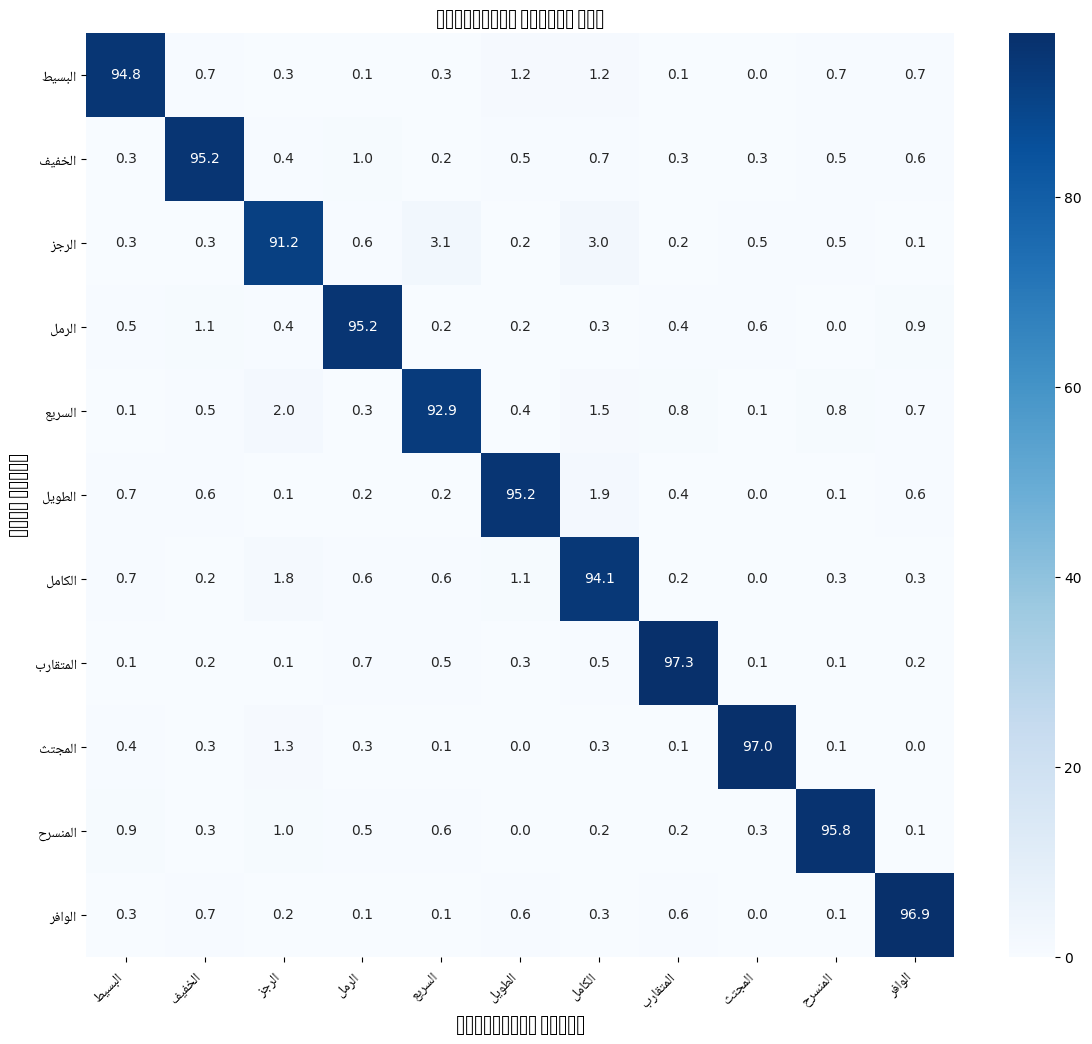

In [37]:
import numpy as np
import json
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Install reshaper libraries (Colab)
!pip install arabic-reshaper python-bidi --quiet

import arabic_reshaper
from bidi.algorithm import get_display

# Download Arabic font
!wget -q -O /usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf \
    https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf

arabic_font = fm.FontProperties(fname='/usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf')

# Load mapping
with open("id_to_meter.json", "r", encoding="utf-8") as f:
    id_to_meter = json.load(f)

# Prepare class names with reshaping + bidi
class_names = [get_display(arabic_reshaper.reshape(id_to_meter[str(i)])) for i in range(len(id_to_meter))]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(14,12))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Meter", fontproperties=arabic_font)
plt.ylabel("True Meter", fontproperties=arabic_font)
plt.title("Confusion Matrix (%)", fontproperties=arabic_font)

plt.xticks(rotation=45, ha='right', fontproperties=arabic_font)
plt.yticks(rotation=0, fontproperties=arabic_font)

plt.show()

In [38]:
report = classification_report(y_true, y_pred, digits=3)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0      0.958     0.948     0.953      3000
           1      0.952     0.952     0.952      3000
           2      0.929     0.912     0.921      3000
           3      0.957     0.952     0.955      3000
           4      0.942     0.929     0.935      3000
           5      0.956     0.952     0.954      3000
           6      0.907     0.941     0.923      3000
           7      0.968     0.973     0.970      3000
           8      0.959     0.970     0.964      1434
           9      0.966     0.958     0.962      2839
          10      0.958     0.969     0.964      3000

    accuracy                          0.950     31273
   macro avg      0.950     0.951     0.950     31273
weighted avg      0.950     0.950     0.950     31273

